# Evaluation — U-Net Semantic Segmentation
Evaluation of the trained model on a satellite imagery dataset. Includes prediction visualization, a confusion matrix, and IoU metrics.

In [95]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from model import UNet


## 2. Loading the model

In [96]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

model = UNet(n_classes=5)
model.load_state_dict(torch.load("unet_best.pth", map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully")


Device: mps
Model loaded successfully


## 3. Loading the data

In [97]:
images = np.load("./data/filtered_images.npy")
masks = np.load("./data/filtered_masks.npy")

print(f"Images: {images.shape}")
print(f"Masks:  {masks.shape}")


Images: (2652, 256, 256, 3)
Masks:  (2652, 256, 256)


### Checking the distribution of classes across the splits.
Ensure that all 5 classes are present in both the training and validation sets.

In [98]:
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("All classes in dataset: ", np.unique(masks))
print("Classes in train:        ", np.unique(y_train))
print("Classes in val:          ", np.unique(y_val))


Всі класи в датасеті:  [0 1 2 3 4]
Класи в train:         [0 1 2 3 4]
Класи в val:           [0 1 2 3 4]


## 4. Visualization of predictions
Select a random patch containing at least 4 different classes for a clear visual demonstration.

In [99]:
# colours for all the classes
class_colors = {
    0: [0, 0, 0],        # background
    1: [255, 0, 0],      # buildings
    2: [0, 255, 0],      # forest
    3: [0, 0, 255],      # water
    4: [255, 255, 0],    # road
}

def mask_to_color(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in class_colors.items():
        color_mask[mask == class_id] = color
    return color_mask


In [100]:
# search for a patch containing at least 4 different classes
indices = list(range(len(masks)))
random.shuffle(indices)

for i in indices:
    unique = np.unique(masks[i])
    if len(unique) >= 4:
        idx = i
        break

image = images[idx]
true_mask = masks[idx]

print(f"Chosen patch #{idx}, class: {np.unique(true_mask)}")


Обраний патч #975, класи: [0 1 2 4]


In [101]:
# receive the prediction of the model
input_tensor = torch.tensor(image).permute(2, 0, 1).unsqueeze(0).float().to(device)

with torch.no_grad():
    output = model(input_tensor)

pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

# prepare masks and overlay
true_color = mask_to_color(true_mask)
pred_color = mask_to_color(pred_mask)
image_uint8 = (image * 255).astype(np.uint8)
overlay_true = (0.6 * image_uint8 + 0.4 * true_color).astype(np.uint8)
overlay_pred = (0.6 * image_uint8 + 0.4 * pred_color).astype(np.uint8)


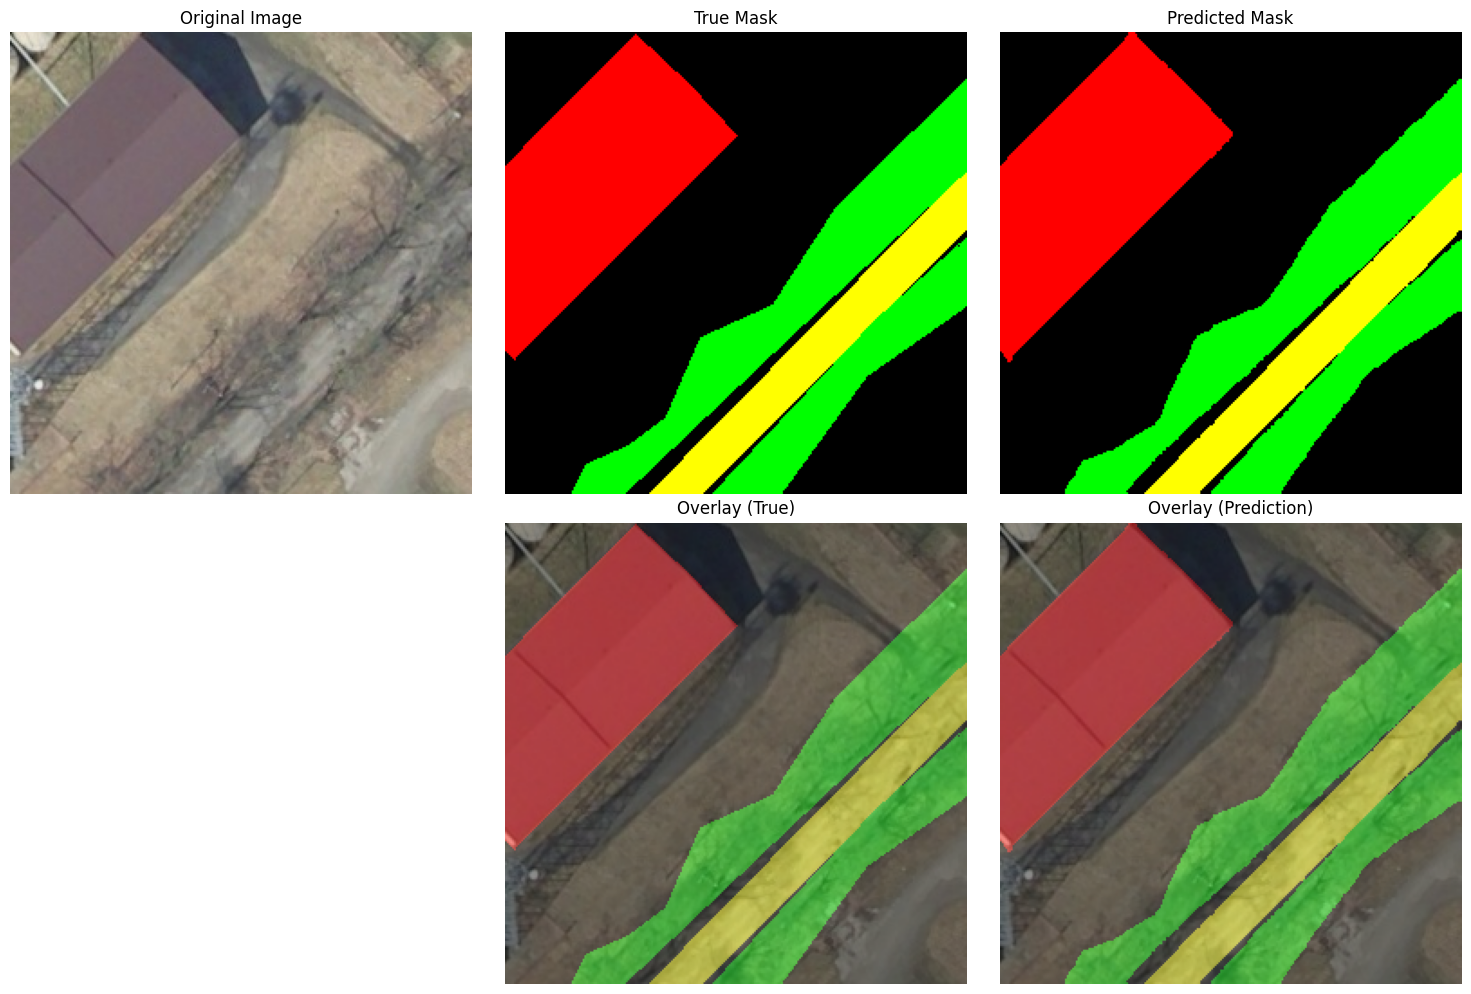

In [102]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image_uint8)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("True Mask")
plt.imshow(true_color)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_color)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Overlay (True)")
plt.imshow(overlay_true)
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Overlay (Prediction)")
plt.imshow(overlay_pred)
plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Confusion Matrix and metrics
Compute the confusion matrix over the entire dataset, then calculate Pixel Accuracy and IoU for each class.

In [103]:
num_classes = 5
conf_matrix = np.zeros((num_classes, num_classes))

with torch.no_grad():
    for i in range(len(images)):
        img = images[i]
        true_mask = masks[i]

        input_tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(device)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

        pred_flat = pred_mask.flatten()
        true_flat = true_mask.flatten()

        for t, p in zip(true_flat, pred_flat):
            if t < num_classes:
                conf_matrix[t, p] += 1

print("Confusion matrix built")


KeyboardInterrupt: 

### Pixel Accuracy and IoU per class

In [12]:
accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)
print(f"Pixel Accuracy: {accuracy:.4f}")
print()

iou_per_class = []

for i in range(num_classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    iou = TP / (TP + FP + FN + 1e-6)
    iou_per_class.append(iou)
    print(f"Class {i} IoU: {iou:.4f}")

print()
print(f"Mean IoU: {np.mean(iou_per_class):.4f}")


Pixel Accuracy: 0.9900

Class 0 IoU: 0.9852
Class 1 IoU: 0.9632
Class 2 IoU: 0.9762
Class 3 IoU: 0.9613
Class 4 IoU: 0.9534

Mean IoU: 0.9679


## 6. Checking predicted classes
Verify that the model actually predicts all 5 classes and does not collapse into the dominant class.

In [13]:
unique_preds = set()

for i in range(50):
    input_tensor = torch.tensor(images[i]).permute(2, 0, 1).unsqueeze(0).float().to(device)
    output = model(input_tensor)
    pred = torch.argmax(output, dim=1).cpu().numpy()
    unique_preds.update(np.unique(pred))

print("Predicted classes (first 50):", sorted(unique_preds))


Передбачені класи (перші 50 зразків): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
